# Elliptic Bitcoin Transactions: Features and Splits

Notebook 2 of 7. It fixes every split used by later notebooks (five contiguous time-step folds inside the training period, plus a stratified random split for the contrast in notebook 6), selects the 34 local attributes used for neighbourhood aggregation, and computes 177 engineered graph features with NetworkX for all 203,769 transactions.

Decisions carried over from the EDA: no edge crosses time steps, so features are computed per step and folds of whole steps are leak-free; the time step itself is not a model input.

## Setup

Imports, constants, helpers and the graph feature functions. The functions are identical to `app/graph.py` in the serving app, so the live API computes exactly the features the models were trained on. `SMOKE` switches to a quick check on nine time steps; it is off in this version.

In [1]:
import json
import time
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from cycler import cycler
from scipy import sparse
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split

SMOKE = False
SEED = 42
THREADS = 4
TRAIN_LAST = 34
N_ATTRS = 34
SMOKE_STEPS = [1, 2, 3, 4, 5, 6, 35, 36, 37]
INPUT = Path("/kaggle/input")
OUT = Path("/kaggle/working")
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "text.color": INK, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2, "legend.frameon": False,
    "font.family": "sans-serif", "axes.prop_cycle": cycler(color=SERIES), "axes.titlesize": 11,
})
LOCAL = [f"local_{i}" for i in range(1, 94)]
AGG = [f"agg_{i}" for i in range(1, 73)]
RAW = LOCAL + AGG
START = time.time()

STRUCTURAL = ["in_degree", "out_degree", "pagerank", "core_number", "clustering", "avg_neighbor_degree", "two_hop_size"]
AGGREGATES = ["in_mean", "in_max", "out_mean", "out_max", "hop2_mean"]
STACKING = ["gnn_logit", "gnn_in_mean", "gnn_in_max", "gnn_out_mean", "gnn_out_max"]


def engineered_names(attrs):
    return STRUCTURAL + [f"{attr}_{agg}" for attr in attrs for agg in AGGREGATES]


def directed(n, src, dst):
    src = np.asarray(src, dtype=np.int64)
    dst = np.asarray(dst, dtype=np.int64)
    keep = src != dst
    matrix = sparse.csr_matrix((np.ones(int(keep.sum())), (src[keep], dst[keep])), shape=(n, n))
    matrix.sum_duplicates()
    matrix.data[:] = 1.0
    return matrix


def undirected(forward):
    matrix = (forward + forward.T).tocsr()
    matrix.data[:] = 1.0
    return matrix


def two_hop(und):
    n = und.shape[0]
    reach = (und + und @ und).tocoo()
    off = reach.row != reach.col
    return sparse.csr_matrix((np.ones(int(off.sum())), (reach.row[off], reach.col[off])), shape=(n, n))


def segment_mean(matrix, values):
    counts = np.diff(matrix.indptr).astype(float)
    sums = np.asarray(matrix @ values, dtype=float)
    out = np.full(sums.shape, np.nan)
    has = counts > 0
    out[has] = sums[has] / counts[has, None]
    return out


def segment_max(matrix, values):
    out = np.full((matrix.shape[0], values.shape[1]), np.nan)
    has = np.diff(matrix.indptr) > 0
    if has.any():
        out[has] = np.maximum.reduceat(values[matrix.indices], matrix.indptr[:-1][has], axis=0)
    return out


def graph_features(n, src, dst, sel):
    sel = np.asarray(sel, dtype=float).reshape(n, -1)
    forward = directed(n, src, dst)
    backward = forward.T.tocsr()
    reach = two_hop(undirected(forward))
    rows, cols = forward.nonzero()
    digraph = nx.DiGraph()
    digraph.add_nodes_from(range(n))
    digraph.add_edges_from(zip(rows.tolist(), cols.tolist()))
    graph = digraph.to_undirected()
    rank = nx.pagerank(digraph, alpha=0.85)
    core = nx.core_number(graph)
    clustering = nx.clustering(graph)
    neighbour_degree = nx.average_neighbor_degree(graph)
    structural = np.column_stack([
        np.diff(backward.indptr),
        np.diff(forward.indptr),
        [rank[i] for i in range(n)],
        [core[i] for i in range(n)],
        [clustering[i] for i in range(n)],
        [neighbour_degree[i] for i in range(n)],
        np.diff(reach.indptr),
    ]).astype(float)
    blocks = np.stack([
        segment_mean(backward, sel),
        segment_max(backward, sel),
        segment_mean(forward, sel),
        segment_max(forward, sel),
        segment_mean(reach, sel),
    ], axis=2)
    return np.hstack([structural, blocks.reshape(n, -1)])


def find_file(name):
    hits = sorted(INPUT.rglob(name))
    if not hits:
        raise FileNotFoundError(name)
    return hits[0]


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def elapsed():
    return f"elapsed {(time.time() - START) / 60:.1f} minutes"


print(f"smoke={SMOKE}")
print(f"networkx {nx.__version__}, lightgbm {lgb.__version__}, pandas {pd.__version__}")

smoke=False
networkx 3.6.1, lightgbm 4.6.0, pandas 2.3.3


**Conclusion.** The smoke switch is off, so every time step is processed. NetworkX 3.6.1 and LightGBM 4.6.0 come preinstalled on Kaggle, so this notebook runs without internet access.

## Load the data

Aim: rebuild the node table exactly as in notebook 1 (named columns, float32 features, labels 1 illicit, 0 licit, -1 unknown) and map every edge to the time step of its endpoints.

In [2]:
features = pd.read_csv(find_file("elliptic_txs_features.csv"), header=None)
features.columns = ["txId", "time_step"] + RAW
features[RAW] = features[RAW].astype(np.float32)
classes = pd.read_csv(find_file("elliptic_txs_classes.csv"))
classes["class"] = classes["class"].astype(str)
edges = pd.read_csv(find_file("elliptic_txs_edgelist.csv"))
features = features.merge(classes, on="txId", how="left")
features["label"] = features["class"].map({"1": 1, "2": 0, "unknown": -1}).astype(np.int8)
features = features.drop(columns="class")
if SMOKE:
    features = features[features.time_step.isin(SMOKE_STEPS)].reset_index(drop=True)
    keep = set(features.txId)
    edges = edges[edges.txId1.isin(keep) & edges.txId2.isin(keep)].reset_index(drop=True)
N = len(features)
pos = pd.Series(np.arange(N), index=features.txId.to_numpy())
src_all = pos.loc[edges.txId1].to_numpy()
dst_all = pos.loc[edges.txId2].to_numpy()
step_arr = features.time_step.to_numpy()
edge_step = step_arr[src_all]
print(f"nodes {N:,}, edges {len(edges):,}, steps {len(np.unique(step_arr))}")
print(f"edges whose endpoints share a step: {(step_arr[src_all] == step_arr[dst_all]).mean():.4f}")

nodes 203,769, edges 234,355, steps 49
edges whose endpoints share a step: 1.0000


**Conclusion.** The node table matches notebook 1: 203,769 transactions, 234,355 edges and 49 time steps, and every edge's endpoints share a step (share 1.0000), so per-step processing loses no edge.

## Temporal folds

Aim: split the training period (steps 1 to 34) into five contiguous blocks of whole time steps with roughly equal labelled counts. Every later tuning study, out-of-fold prediction and threshold uses these folds; because no edge crosses steps, a held-out fold's nodes and their neighbourhoods are absent from the models that score them.

In [3]:
train_steps = np.array(sorted(s for s in np.unique(step_arr) if s <= TRAIN_LAST))
labelled_per_step = features[features.label >= 0].groupby("time_step").size().reindex(train_steps, fill_value=0)
cum = labelled_per_step.cumsum().to_numpy()
cuts = []
for k in range(1, 5):
    cut = int(np.argmin(np.abs(cum - cum[-1] * k / 5)))
    if cuts:
        cut = max(cut, cuts[-1] + 1)
    cuts.append(cut)
fold_of_step = {int(s): int(np.searchsorted(cuts, i, side="left")) for i, s in enumerate(train_steps)}
features["temporal_fold"] = features.time_step.map(fold_of_step).fillna(-1).astype(np.int8)
fold_steps = {k: [s for s, f in fold_of_step.items() if f == k] for k in range(5)}
for k in range(5):
    part = features[(features.temporal_fold == k) & (features.label >= 0)]
    print(f"fold {k}: steps {fold_steps[k][0]}-{fold_steps[k][-1]}, labelled {len(part):,}, illicit {int((part.label == 1).sum()):,}")
test_lab = features[(features.time_step > TRAIN_LAST) & (features.label >= 0)]
print(f"test steps: labelled {len(test_lab):,}, illicit {int((test_lab.label == 1).sum()):,}")

fold 0: steps 1-4, labelled 5,983, illicit 76
fold 1: steps 5-9, labelled 5,513, illicit 430
fold 2: steps 10-19, labelled 6,493, illicit 1,005
fold 3: steps 20-25, labelled 6,211, illicit 826
fold 4: steps 26-34, labelled 5,694, illicit 1,125
test steps: labelled 16,670, illicit 1,083


**Conclusion.** The five folds are contiguous blocks of whole time steps with similar labelled counts (5,513 to 6,493 each): steps 1-4, 5-9, 10-19, 20-25 and 26-34. Illicit counts are far less even, from 76 in fold 0 to 1,125 in fold 4, because early steps hold few illicit transactions. Single-fold scores will therefore be noisy, which is why tuning and thresholds use pooled out-of-fold predictions rather than per-fold averages. The test period keeps 16,670 labelled transactions, 1,083 of them illicit.

## Random split for the contrast

Aim: build the leaky comparison protocol used only in notebook 6: a stratified random split of all labelled nodes whose test set has exactly the temporal test set's size, with five stratified folds inside the random training part.

In [4]:
labelled = features[features.label >= 0]
n_test = len(test_lab)
r_train, r_test = train_test_split(labelled.txId.to_numpy(), test_size=n_test, stratify=labelled.label.to_numpy(), random_state=SEED)
label_of = labelled.set_index("txId")["label"]
random_set = pd.Series("none", index=features.txId.to_numpy(), dtype=object)
random_set.loc[r_train] = "train"
random_set.loc[r_test] = "test"
random_fold = pd.Series(-1, index=features.txId.to_numpy(), dtype=np.int8)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for k, (_, idx) in enumerate(skf.split(r_train, label_of.loc[r_train].to_numpy())):
    random_fold.loc[r_train[idx]] = k
features["random_set"] = random_set.to_numpy()
features["random_fold"] = random_fold.to_numpy()
print(f"random train {len(r_train):,} (illicit {int((label_of.loc[r_train] == 1).sum()):,}), random test {len(r_test):,} (illicit {int((label_of.loc[r_test] == 1).sum()):,})")
print(features[features.random_set == "train"].groupby("random_fold").label.agg(["size", "sum"]).to_string())

random train 29,894 (illicit 2,918), random test 16,670 (illicit 1,627)
             size  sum
random_fold           
0            5979  583
1            5979  584
2            5979  584
3            5979  584
4            5978  583


**Conclusion.** The random split mirrors the temporal test size (16,670 transactions) and stratifies on the label over all 49 steps, so its test set is 9.76% illicit (1,627 of 16,670) against 6.50% in the temporal test period. The five random folds are balanced to within one illicit transaction. Because PR-AUC depends on the base rate, notebook 6 compares the protocols mainly on AUC-ROC, F1 and recall.

## Select the 34 attributes

Aim: choose the local attributes worth aggregating over neighbourhoods. A default LightGBM on the 93 local features is fitted once per temporal fold, on the other four folds, and the 34 attributes with the highest mean gain are kept. Only training steps are used, so the selection never sees the test period.

          gain_share
local_53      0.3479
local_90      0.1364
local_5       0.0889
local_2       0.0553
local_59      0.0463
local_41      0.0357
local_80      0.0279
local_40      0.0216
local_76      0.0194
local_46      0.0186
local_55      0.0152
local_3       0.0133
local_23      0.0119
local_47      0.0117
local_16      0.0107
local_8       0.0096
local_58      0.0089
local_52      0.0087
local_22      0.0087
local_61      0.0063
local_18      0.0054
local_1       0.0050
local_71      0.0046
local_83      0.0044
local_89      0.0044
local_77      0.0042
local_88      0.0042
local_54      0.0041
local_9       0.0036
local_29      0.0033
local_73      0.0032
local_67      0.0032
local_64      0.0028
local_17      0.0027
gain covered by the 34 attributes: 95.85%


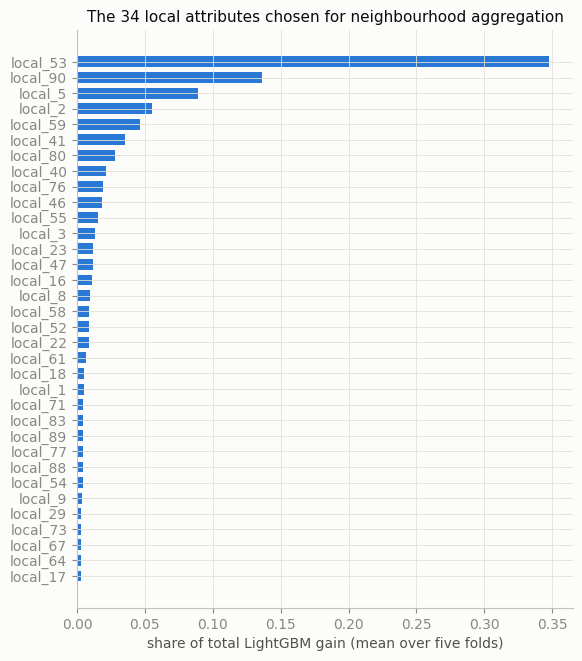

In [5]:
train_lab = features[(features.time_step <= TRAIN_LAST) & (features.label >= 0)]
gains = []
for k in range(5):
    part = train_lab[train_lab.temporal_fold != k]
    model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=SEED, deterministic=True, force_col_wise=True, n_jobs=THREADS, verbose=-1)
    model.fit(part[LOCAL], part.label)
    gains.append(model.booster_.feature_importance(importance_type="gain"))
gain = pd.Series(np.mean(gains, axis=0), index=LOCAL).sort_values(ascending=False)
ATTRS = list(gain.index[:N_ATTRS])
share = gain / gain.sum()
print(pd.DataFrame({"gain_share": share.head(N_ATTRS)}).round(4).to_string())
print(f"gain covered by the 34 attributes: {share.head(N_ATTRS).sum():.2%}")
top = share.head(N_ATTRS)[::-1]
fig, ax = plt.subplots(figsize=(6.4, 7.5))
ax.barh(top.index, top.to_numpy(), color=SERIES[0], height=0.7)
ax.set(xlabel="share of total LightGBM gain (mean over five folds)", title="The 34 local attributes chosen for neighbourhood aggregation")
save(fig, "attribute_selection")

**Conclusion.** The selection is concentrated: local_53 alone carries 34.8% of the gain, followed by local_90 (13.6%), local_5 (8.9%) and local_2 (5.5%), and the 34 chosen attributes cover 95.85% of the total gain of the 93 local features. These 34 become the attributes behind the resume's "graph-neighbourhood features across 34 anonymized attributes".

## Graph features per time step

Aim: compute the 7 structural features and the 170 neighbourhood aggregates (mean and max over inputs, mean and max over outputs, mean within two hops, for each of the 34 attributes) on every time step's own subgraph. No feature uses labels, so nothing about a transaction's class or its neighbours' classes leaks in.

In [6]:
ENG = engineered_names(ATTRS)
sel_values = features[ATTRS].to_numpy(dtype=np.float64)
eng = np.zeros((N, len(ENG)), dtype=np.float32)
for step in np.unique(step_arr):
    nodes = np.flatnonzero(step_arr == step)
    mask = edge_step == step
    src = np.searchsorted(nodes, src_all[mask])
    dst = np.searchsorted(nodes, dst_all[mask])
    eng[nodes] = graph_features(len(nodes), src, dst, sel_values[nodes]).astype(np.float32)
eng_frame = pd.DataFrame(eng, columns=ENG)
print(f"engineered features: {len(ENG)} ({len(STRUCTURAL)} structural, {len(ENG) - len(STRUCTURAL)} aggregates)")
print(eng_frame[STRUCTURAL].describe().T[["mean", "50%", "max"]].round(4).to_string())
for agg in AGGREGATES:
    print(f"share of nodes with no neighbours for {agg}: {eng_frame[f'{ATTRS[0]}_{agg}'].isna().mean():.4f}")
print(elapsed())

engineered features: 177 (7 structural, 170 aggregates)
                        mean     50%       max
in_degree             1.1501  1.0000  284.0000
out_degree            1.1501  1.0000  472.0000
pagerank              0.0002  0.0001    0.0266
core_number           1.3756  1.0000    9.0000
clustering            0.0138  0.0000    1.0000
avg_neighbor_degree  12.7731  3.0000  473.0000
two_hop_size         23.2154  5.0000  961.0000
share of nodes with no neighbours for in_mean: 0.2715
share of nodes with no neighbours for in_max: 0.2715
share of nodes with no neighbours for out_mean: 0.1837
share of nodes with no neighbours for out_max: 0.1837
share of nodes with no neighbours for hop2_mean: 0.0000
elapsed 0.7 minutes


**Conclusion.** All 177 engineered features (7 structural, 170 aggregates) were computed for the full graph in under a minute. Neighbourhoods are small but heavy-tailed: the median transaction reaches 5 others within two hops, the largest 961. Input aggregates are missing for 27.15% of transactions and output aggregates for 18.37%, matching the zero in-degree and out-degree shares from notebook 1, while the two-hop mean is never missing because every step is connected.

## Do the graph features carry signal?

Aim: a quick check before any model: mean structural features by class in the training period, and the single-feature AUC of the strongest engineered features against the strongest raw feature.

In [7]:
frame = pd.concat([features[["time_step", "label"]].reset_index(drop=True), eng_frame], axis=1)
train_frame = frame[(frame.time_step <= TRAIN_LAST) & (frame.label >= 0)]
print(train_frame.groupby("label")[STRUCTURAL].mean().round(4).to_string())
filled = train_frame[ENG].fillna(train_frame[ENG].median())
eng_auc = pd.Series({c: roc_auc_score(train_frame.label, filled[c]) for c in ENG})
eng_sep = (eng_auc - 0.5).abs().sort_values(ascending=False)
raw_auc = pd.Series({c: roc_auc_score(train_lab.label, train_lab[c]) for c in RAW})
raw_sep = (raw_auc - 0.5).abs().sort_values(ascending=False)
print(pd.DataFrame({"auc": eng_auc[eng_sep.index[:10]]}).round(4).to_string())
print(f"strongest raw feature: {raw_sep.index[0]} with single-feature AUC {raw_auc[raw_sep.index[0]]:.4f}")

       in_degree  out_degree  pagerank  core_number  clustering  avg_neighbor_degree  two_hop_size
label                                                                                             
0         1.8251      1.1464    0.0003       1.3997      0.0092              16.5177     30.871799
1         1.2631      0.7669    0.0002       1.1863      0.0002              13.3635     18.712299
                       auc
local_90_hop2_mean  0.2027
local_54_hop2_mean  0.2138
local_59_hop2_mean  0.2262
local_53_hop2_mean  0.2272
local_23_hop2_mean  0.2316
local_29_hop2_mean  0.2316
local_89_hop2_mean  0.2333
local_61_hop2_mean  0.2335
local_67_hop2_mean  0.2335
local_55_hop2_mean  0.2421
strongest raw feature: local_53 with single-feature AUC 0.1452


**Conclusion.** Structural features differ by class in the training period: illicit transactions have fewer inputs (mean in-degree 1.26 against 1.83), fewer outputs (0.77 against 1.15), almost no clustering (0.0002 against 0.0092) and smaller two-hop neighbourhoods (18.7 against 30.9). The ten strongest engineered features are all two-hop means, led by local_90_hop2_mean with a single-feature AUC of 0.203 (0.797 flipped), against 0.145 (0.855 flipped) for the strongest raw feature, local_53. Neighbourhood features carry real signal without replacing the node's own attributes, which supports giving models both.

## Write the outputs

Aim: save the feature matrix, edges, splits and metadata that notebooks 3 to 7 consume, and record their sizes.

In [8]:
out = pd.concat([features[["txId", "time_step", "label"] + RAW].reset_index(drop=True), eng_frame], axis=1)
out.to_parquet(OUT / "features.parquet", index=False)
edges.to_parquet(OUT / "edges.parquet", index=False)
features[["txId", "time_step", "label", "temporal_fold", "random_set", "random_fold"]].to_parquet(OUT / "split.parquet", index=False)
meta = {
    "raw": RAW, "local": LOCAL, "aggregated": AGG, "attrs": ATTRS,
    "attr_gain_share": {a: float(share[a]) for a in ATTRS},
    "structural": STRUCTURAL, "engineered": ENG, "train_last": TRAIN_LAST,
    "fold_steps": {str(k): v for k, v in fold_steps.items()},
    "counts": {"nodes": int(N), "edges": int(len(edges)), "labelled": int((features.label >= 0).sum()), "illicit": int((features.label == 1).sum())},
    "smoke": SMOKE,
}
(OUT / "feature_meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
for name in ["features.parquet", "edges.parquet", "split.parquet", "feature_meta.json"]:
    print(f"{name}: {(OUT / name).stat().st_size / 1e6:.1f} MB")
print(elapsed())

features.parquet: 146.2 MB
edges.parquet: 2.5 MB
split.parquet: 1.4 MB
feature_meta.json: 0.0 MB
elapsed 0.8 minutes


**Conclusion.** The outputs are written: features.parquet (146.2 MB, raw and engineered features for every transaction), edges.parquet (2.5 MB), split.parquet (1.4 MB, temporal folds and the random split) and feature_meta.json. Notebooks 3 to 7 read these as their inputs.